In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')
df.shape

(1000, 3)

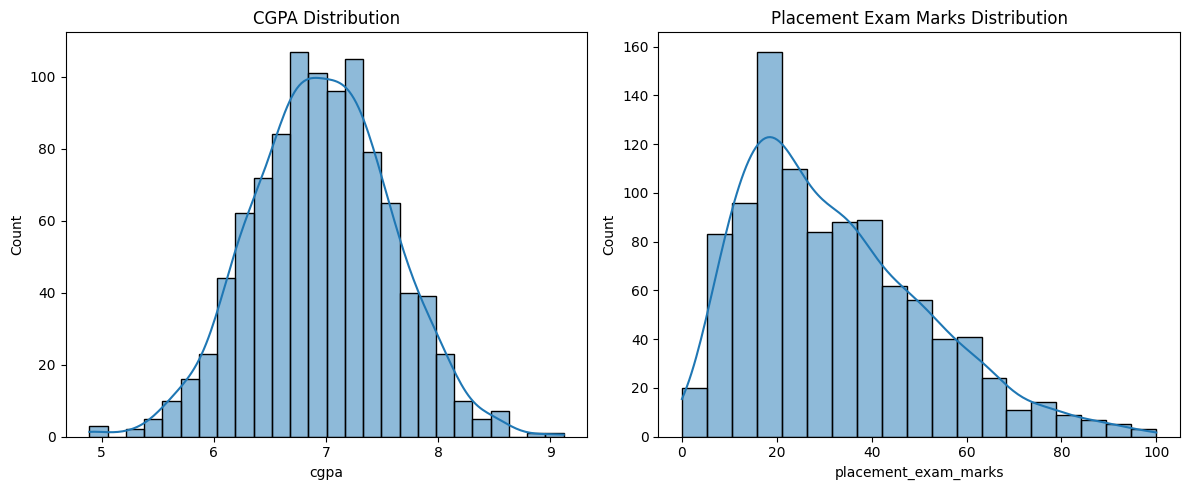

In [3]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('CGPA Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Placement Exam Marks Distribution')

plt.tight_layout()
plt.show()

In [5]:
# iqr implemented when the data is skewed and has outliers
df["placement_exam_marks"].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [6]:
df["placement_exam_marks"].skew()

np.float64(0.8356419499466834)

<Axes: ylabel='placement_exam_marks'>

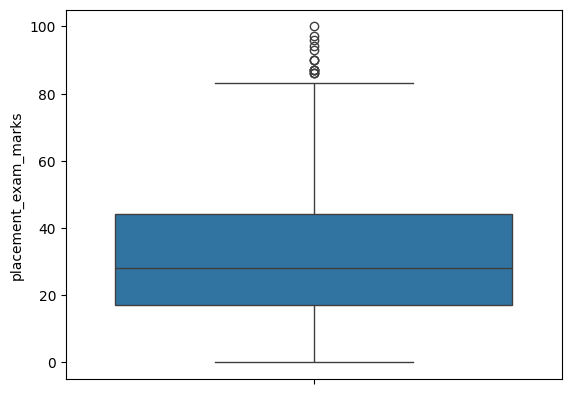

In [7]:
sns.boxplot(df['placement_exam_marks'])

In [8]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [9]:
percentile75

np.float64(44.0)

In [10]:
iqr = percentile75 - percentile25

In [11]:
iqr

np.float64(27.0)

In [12]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [13]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


In [15]:
#Finding Outliers
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [16]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [17]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [18]:
new_df.shape

(985, 3)

In [19]:
new_df.shape

(985, 3)

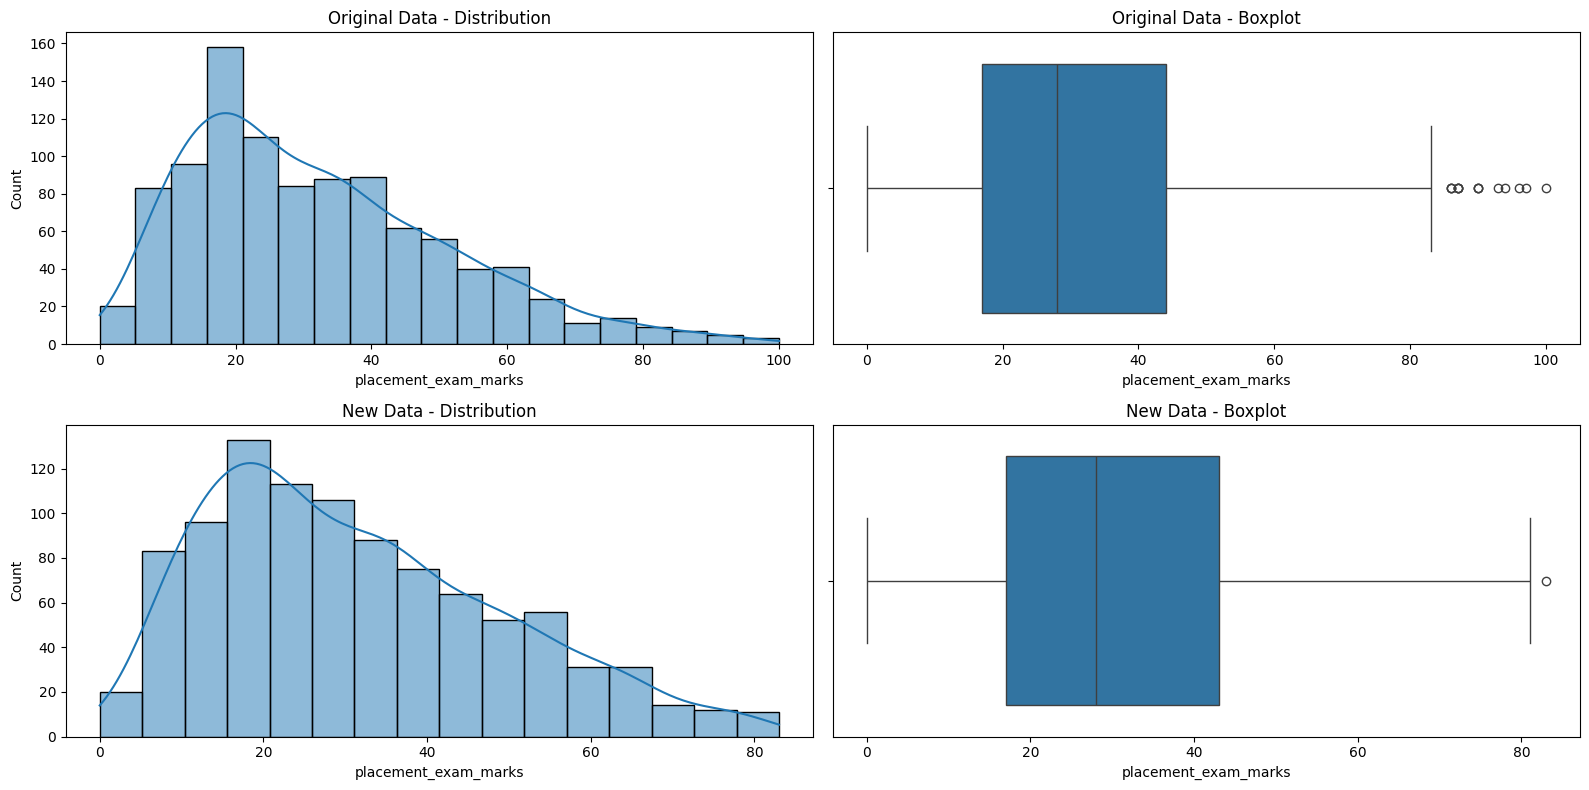

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

# Original dataframe - distribution
plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title("Original Data - Distribution")

# Original dataframe - boxplot
plt.subplot(2, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title("Original Data - Boxplot")

# New dataframe - distribution
plt.subplot(2, 2, 3)
sns.histplot(new_df['placement_exam_marks'], kde=True)
plt.title("New Data - Distribution")

# New dataframe - boxplot
plt.subplot(2, 2, 4)
sns.boxplot(x=new_df['placement_exam_marks'])
plt.title("New Data - Boxplot")

plt.tight_layout()
plt.show()


In [21]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [22]:
new_df_cap.shape

(1000, 3)

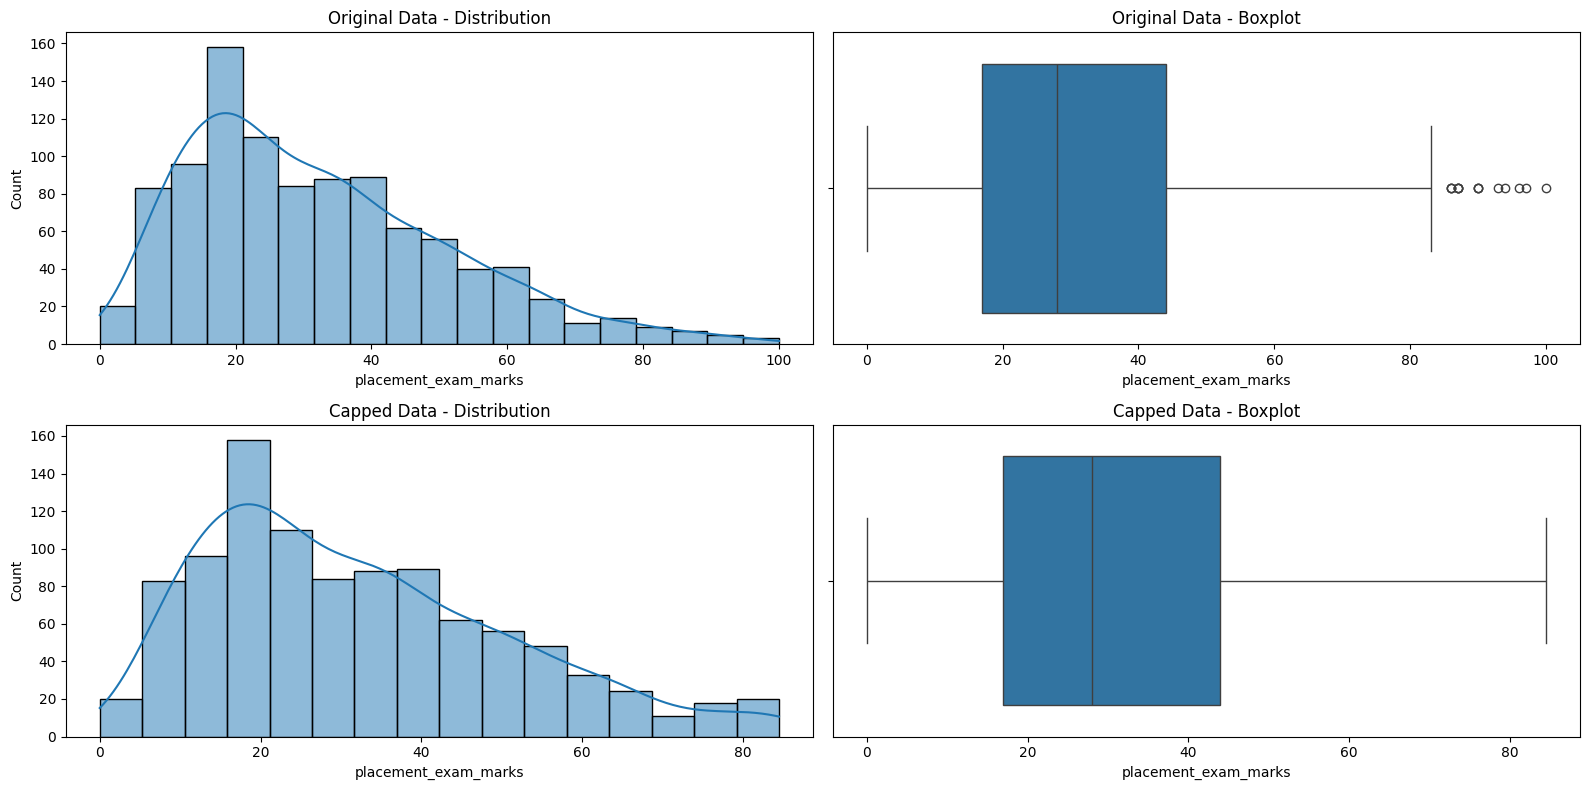

In [23]:


# Comparing
plt.figure(figsize=(16, 8))

# Original data - distribution
plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title("Original Data - Distribution")

# Original data - boxplot
plt.subplot(2, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title("Original Data - Boxplot")

# Capped data - distribution
plt.subplot(2, 2, 3)
sns.histplot(new_df_cap['placement_exam_marks'], kde=True)
plt.title("Capped Data - Distribution")

# Capped data - boxplot
plt.subplot(2, 2, 4)
sns.boxplot(x=new_df_cap['placement_exam_marks'])
plt.title("Capped Data - Boxplot")

plt.tight_layout()
plt.show()
